<a href="https://colab.research.google.com/github/ArnavCodes1000101/python_assignment_IIT/blob/main/08_24_2026_(Assignment02)_Arnav_Gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generated Signal Components:
---------------------------------------------
Component  1: Amplitude = 0.918 V, Frequency = 32 Hz
Component  2: Amplitude = 0.423 V, Frequency = 50 Hz
Component  3: Amplitude = 0.528 V, Frequency = 26 Hz
Component  4: Amplitude = 0.905 V, Frequency = 12 Hz
Component  5: Amplitude = 0.371 V, Frequency = 46 Hz
Component  6: Amplitude = 0.382 V, Frequency = 15 Hz
Component  7: Amplitude = 0.391 V, Frequency = 38 Hz
Component  8: Amplitude = 0.889 V, Frequency = 48 Hz
Component  9: Amplitude = 0.985 V, Frequency = 42 Hz
Component 10: Amplitude = 0.224 V, Frequency = 47 Hz
Sampling frequency = 1000 Hz
Signal duration = 2 seconds
Number of samples = 2000
10 sinusoidal signals have been generated.


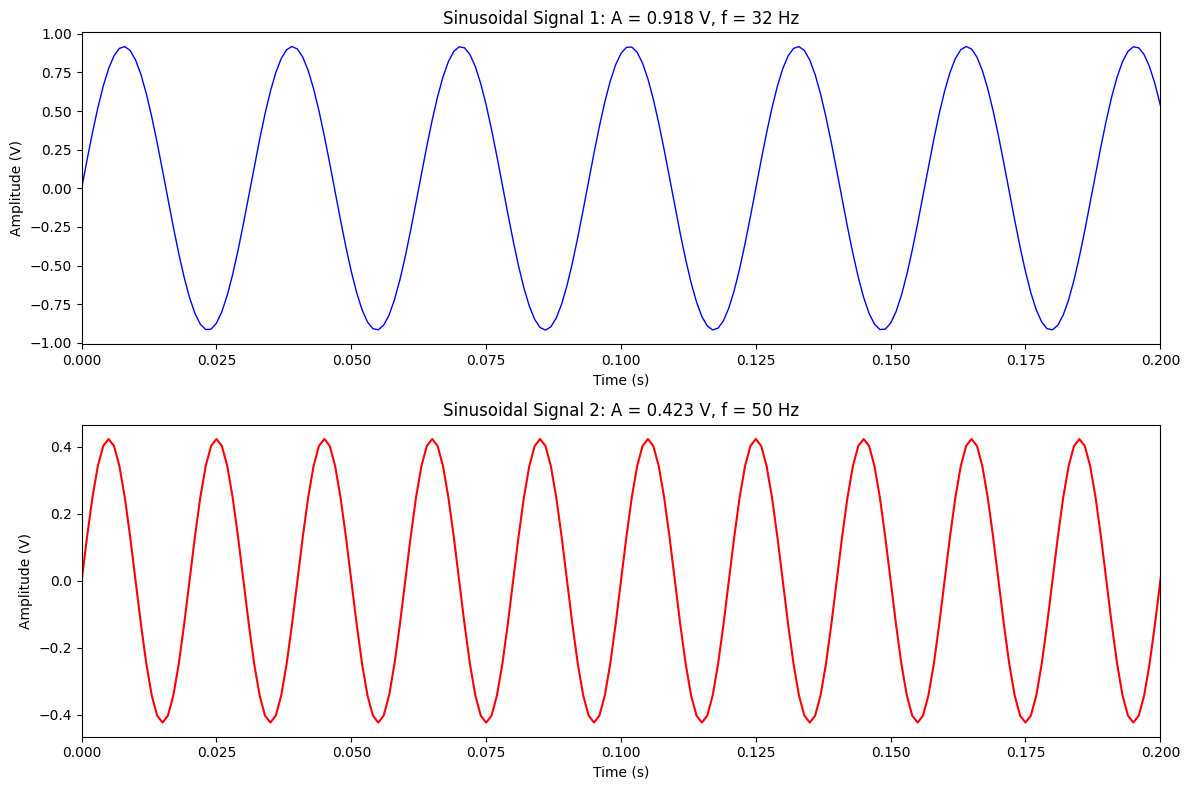

Resultant signal created.
Maximum amplitude: 5.119 V
Minimum amplitude: -5.119 V


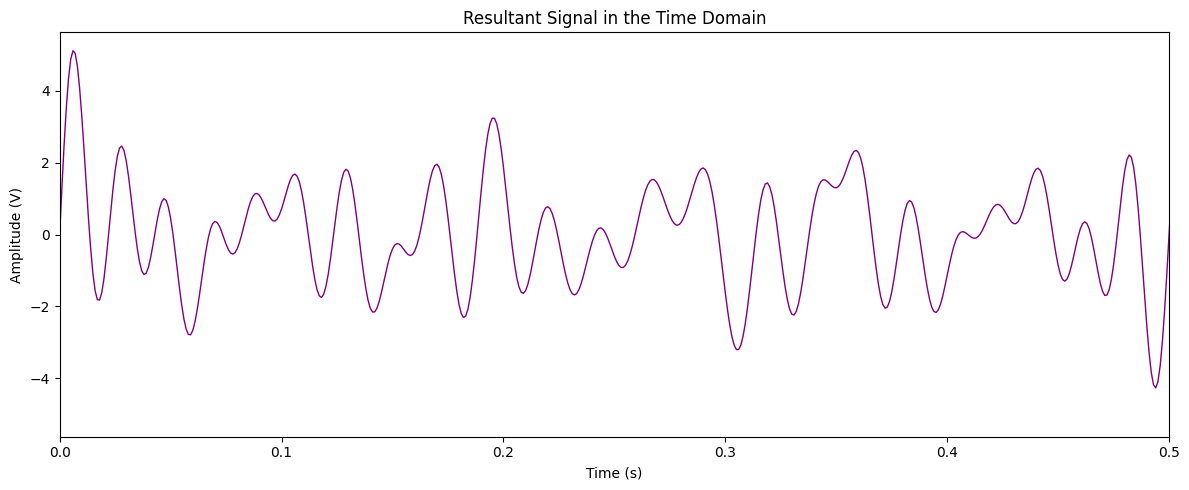

Number of FFT samples = 2000


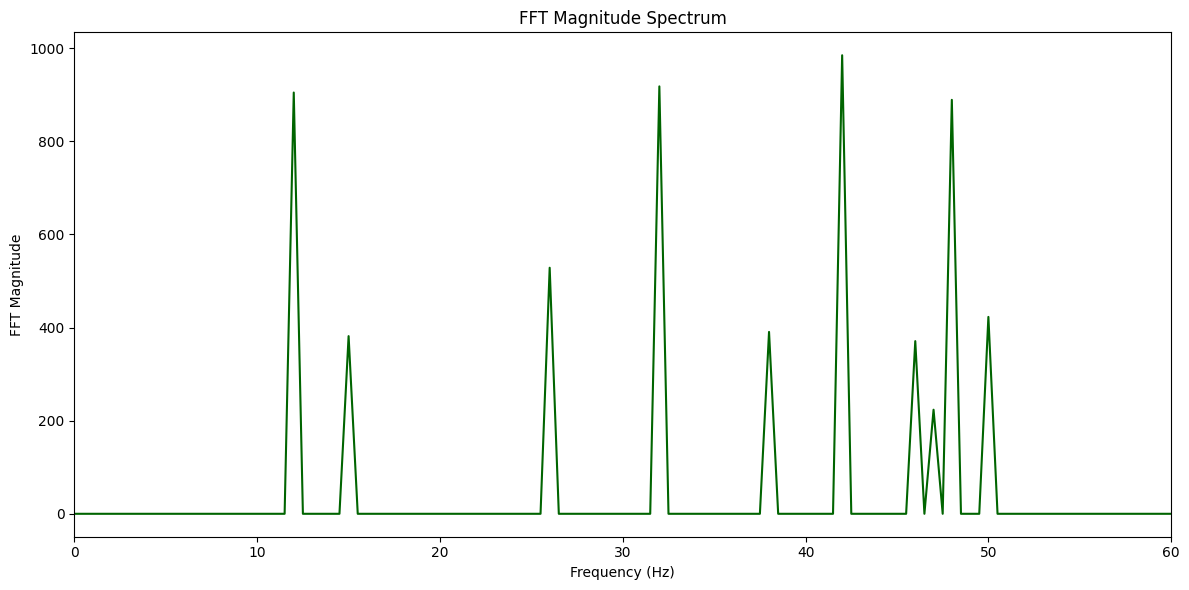

                                        
Frequencies detected from FFT:
-----------------------------------
Peak 1: 12.00 Hz
Peak 2: 15.00 Hz
Peak 3: 26.00 Hz
Peak 4: 32.00 Hz
Peak 5: 38.00 Hz
Peak 6: 42.00 Hz
Peak 7: 46.00 Hz
Peak 8: 47.00 Hz
Peak 9: 48.00 Hz
Peak 10: 50.00 Hz


,Component,Frequency Used (Hz),Frequency from FFT (Hz)
0,1,12,12.0
1,2,15,15.0
2,3,26,26.0
3,4,32,32.0
4,5,38,38.0
5,6,42,42.0
6,7,46,46.0
7,8,47,47.0
8,9,48,48.0
9,10,50,50.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

amplitudes = np.random.uniform(0.1, 1.0, 10)
frequencies = np.random.choice(
    np.arange(10, 51),
    size = 10,
    replace = False)

print("Generated Signal Components:")
print("-" * 45)

for i in range(10):
    print(
        f"Component {i+1:2d}: "
        f"Amplitude = {amplitudes[i]:.3f} V, "
        f"Frequency = {frequencies[i]} Hz" )

component_numbers = np.arange(1, 11)

components_table = pd.DataFrame({
    "Component": component_numbers,
    "Amplitude (V)": amplitudes,
    "Frequency (Hz)": frequencies})

components_table

Fs = 1000
duration = 2
t = np.arange(0, duration, 1/Fs)

print(f"Sampling frequency = {Fs} Hz")
print(f"Signal duration = {duration} seconds")
print(f"Number of samples = {len(t)}")

signals = np.zeros((len(t), 10))

for i in range(10):
    signals[:, i] = amplitudes[i] * np.sin(
        2 * np.pi * frequencies[i] * t )

print("10 sinusoidal signals have been generated.")

plt.figure(figsize = (12, 8))

plt.subplot(2, 1, 1)

plt.plot(
    t,
    signals[:, 0],
    color = 'blue',
    linewidth = 1.0)

plt.title(
    f"Sinusoidal Signal 1: "
    f"A = {amplitudes[0]:.3f} V, "
    f"f = {frequencies[0]} Hz")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.xlim(0, 0.2)

plt.subplot(2, 1, 2)

plt.plot(
    t,
    signals[:, 1],
    color = 'red',
    linewidth = 1.5)

plt.title(
    f"Sinusoidal Signal 2: "
    f"A = {amplitudes[1]:.3f} V, "
    f"f = {frequencies[1]} Hz")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.xlim(0, 0.2)

plt.tight_layout()
plt.show()



resultant_signal = np.sum(signals, axis = 1)

print("Resultant signal created.")
print(f"Maximum amplitude: {np.max(resultant_signal):.3f} V")
print(f"Minimum amplitude: {np.min(resultant_signal):.3f} V")

plt.figure(figsize = (12, 5))

plt.plot(
    t,
    resultant_signal,
    color = 'purple',
    linewidth = 1)

plt.title("Resultant Signal in the Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")

plt.xlim(0, 0.5)

plt.tight_layout()
plt.show()













X = np.fft.fft(resultant_signal)
X_mag = np.abs(X)

N = len(resultant_signal)

freq_axis = np.fft.fftfreq(N, d = 1/Fs)

print(f"Number of FFT samples = {N}")

positive_freq_indices = freq_axis >= 0

positive_frequencies = freq_axis[positive_freq_indices]
positive_magnitude = X_mag[positive_freq_indices]

plt.figure(figsize = (12, 6))

plt.plot(
    positive_frequencies,
    positive_magnitude,
    color = 'darkgreen',
    linewidth = 1.5)

plt.title("FFT Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT Magnitude")

plt.xlim(0, 60)

plt.tight_layout()
plt.show()







search_indices = np.where(
    (positive_frequencies >= 10) &
    (positive_frequencies <= 50))[0]

search_magnitudes = positive_magnitude[search_indices]

top_10_positions = np.argsort(search_magnitudes)[-10:]

peak_indices = search_indices[top_10_positions]

peak_indices = peak_indices[
    np.argsort(positive_frequencies[peak_indices])]

detected_frequencies = positive_frequencies[peak_indices]
detected_magnitudes = positive_magnitude[peak_indices]

print("Frequencies detected from FFT:")
print("-" * 35)

for i, f in enumerate(detected_frequencies):
    print(f"Peak {i+1}: {f:.2f} Hz")

sorted_original_frequencies = np.sort(frequencies)


comparison_table = pd.DataFrame({
    "Component": np.arange(1, 11),
    "Frequency Used (Hz)": sorted_original_frequencies,
    "Frequency from FFT (Hz)": detected_frequencies})

comparison_table




1. Why does the resultant signal look complicated in the time domain?

The resultant signal looks complicated because it is made by adding 10 different sinusoidal signals together. Each signal has a different frequency and amplitude, so they combine with each other and create a waveform that is not a simple sine wave. Some signals add together while others cancel each other at different times.

2. Why is it easier to identify the individual components in the frequency domain?

It is easier to identify the components in the frequency domain because the FFT separates the signal into its different frequency components. Each sinusoidal signal produces a peak at its frequency. So, instead of trying to recognize different waves from the complicated time-domain waveform, we can simply look for the peaks in the FFT graph.

3. What does a peak in the FFT magnitude spectrum represent?

A peak in the FFT magnitude spectrum represents a frequency that is present in the original signal. In this experiment, the 10 main peaks represent the 10 sinusoidal signals that were added together. The height of the peak is also related to the amplitude of that frequency component.

4. What happens to the FFT magnitude when the amplitude of a sinusoidal component is increased?

When the amplitude of a sinusoidal signal is increased, the corresponding FFT peak becomes larger. This means that a stronger signal in the time domain produces a higher magnitude in the frequency domain.

7. Engineering Connection

Question: How could frequency-domain analysis help an engineer understand what is happening in the drone?

Frequency-domain analysis can help an engineer find the different sources of vibration in a drone. For example, if one of the drone's motors or propellers is not balanced properly, it may produce a strong vibration at a particular frequency.